# Satellite Trajectory Prediction — GATI v1 (Fixed)

**Changes from original:**
- Train/val TFRecord split (85/15) — no more same-dir overlap
- `repeat()` on datasets so epochs never exhaust mid-way
- `STEPS_PER_EPOCH` and `VALIDATION_STEPS` caps — each epoch finishes in ~2 min
- Checkpoint callback saves best model — resume after session crash
- Auto-resume: loads existing checkpoint if present
- Larger batch size (128) for better GPU utilisation
- `ReduceLROnPlateau` + `EarlyStopping` for smarter training

In [14]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
import os
import glob
import warnings

warnings.filterwarnings('ignore', category=UserWarning)
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.18.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Configuration
All tunable parameters in one place. Adjust `STEPS_PER_EPOCH` based on how long you want each epoch to take.

In [15]:
# ── Paths ────────────────────────────────────────────────────────────────────
FILE_PATH        = '/kaggle/input/30days-5min/satellite_positions_30days_5min_positions.parquet'
TFRECORD_DIR     = 'tfrecord_data'
TRAIN_DIR        = os.path.join(TFRECORD_DIR, 'train')
VAL_DIR          = os.path.join(TFRECORD_DIR, 'val')
MODEL_PATH       = 'trajectory_model_best.keras'   # checkpoint saved here
FINAL_MODEL_PATH = 'trajectory_model_final.keras'

# ── Sequence shape ───────────────────────────────────────────────────────────
INPUT_SEQUENCE_LENGTH = 20
PREDICTION_HORIZON    = 5
FEATURES              = ['x_km', 'y_km', 'z_km']
TARGETS               = ['x_km', 'y_km', 'z_km']
NUM_FEATURES          = len(FEATURES)
NUM_TARGETS           = len(TARGETS)
SAT_ID_COLUMN         = 'sat_id'
TIME_COLUMN           = 'timestamp'

# ── TFRecord writing ─────────────────────────────────────────────────────────
SEQUENCES_PER_FILE    = 50000   # sequences per .tfrecord shard
TRAIN_SPLIT           = 0.85    # 85% shards → train, 15% → val

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE        = 128     # larger = better GPU utilisation
EPOCHS            = 30      # more epochs, each is short
STEPS_PER_EPOCH   = 8000    # 8000 × 128 = ~1M sequences/epoch  (~2 min on T4)
VALIDATION_STEPS  = 800     # 800  × 128 = ~100K sequences for validation
SHUFFLE_BUFFER    = 8000

print('Config loaded.')
print(f'  STEPS_PER_EPOCH : {STEPS_PER_EPOCH}  ({STEPS_PER_EPOCH * BATCH_SIZE:,} sequences)')
print(f'  VALIDATION_STEPS: {VALIDATION_STEPS}  ({VALIDATION_STEPS * BATCH_SIZE:,} sequences)')
print(f'  EPOCHS          : {EPOCHS}')

Config loaded.
  STEPS_PER_EPOCH : 8000  (1,024,000 sequences)
  VALIDATION_STEPS: 800  (102,400 sequences)
  EPOCHS          : 30


## Step 1 — Fit Scalers
Read just the first row group to fit scalers. No need to load the whole file.

In [16]:
position_scaler = MinMaxScaler()

print('Fitting scaler on first row group...')
pq_file     = pq.ParquetFile(FILE_PATH)
first_chunk = pq_file.read_row_group(0).to_pandas()
first_chunk.rename(columns={'sat_id': 'sat_id_str'}, inplace=True)

position_scaler.fit(first_chunk[['x_km', 'y_km', 'z_km']])
del first_chunk
print('Scaler fitted.')

Fitting scaler on first row group...
Scaler fitted.


## Step 2 — Write TFRecords (skip if already done)
Sequences are split into `train/` and `val/` subdirectories at write time.

In [18]:
def _bytes_feature(value):
    """Wrap raw bytes as a TFRecord bytes feature."""
    if isinstance(value, type(tf.constant(0))):
        value = value.numpy()
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))


def serialize_sequence(X_seq, y_seq):
    """Serialise one (X, y) pair to a TFRecord Example string."""
    feature = {
        'X_raw': _bytes_feature(X_seq.astype(np.float32).tobytes()),
        'y_raw': _bytes_feature(y_seq.astype(np.float32).tobytes()),
    }
    proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return proto.SerializeToString()


def create_sequences(data, input_len, pred_len):
    """Sliding-window sequence extraction."""
    X, y = [], []
    total = len(data) - input_len - pred_len + 1
    for i in range(total):
        X.append(data[i : i + input_len, :])
        y.append(data[i + input_len : i + input_len + pred_len, :NUM_TARGETS])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [19]:
# ── Check if TFRecords already exist ────────────────────────────────────────
train_files_existing = glob.glob(os.path.join(TRAIN_DIR, '*.tfrecord'))
val_files_existing   = glob.glob(os.path.join(VAL_DIR,   '*.tfrecord'))

if train_files_existing and val_files_existing:
    print(f'TFRecords already exist — skipping write step.')
    print(f'  Train shards : {len(train_files_existing)}')
    print(f'  Val   shards : {len(val_files_existing)}')
else:
    # ── Create directories ───────────────────────────────────────────────────
    os.makedirs(TRAIN_DIR, exist_ok=True)
    os.makedirs(VAL_DIR,   exist_ok=True)

    sequence_counter    = 0
    shard_index         = 0
    writer              = None
    current_writer_path = None

    pq_file = pq.ParquetFile(FILE_PATH)
    n_groups = pq_file.num_row_groups
    print(f'Writing TFRecords from {n_groups} row groups...')

    for i in range(n_groups):
        print(f'  Row group {i+1}/{n_groups}...', flush=True)
        chunk_df = pq_file.read_row_group(i).to_pandas()
        chunk_df.rename(columns={'sat_id': 'sat_id_str'}, inplace=True)
        chunk_df.sort_values(by=['sat_id_str', TIME_COLUMN], inplace=True)

        for sat_id, sat_df in chunk_df.groupby('sat_id_str'):
            if len(sat_df) < INPUT_SEQUENCE_LENGTH + PREDICTION_HORIZON:
                continue

            # Scale
            scaled = position_scaler.transform(sat_df[['x_km', 'y_km', 'z_km']].values)

            # Generate sequences
            X_sat, y_sat = create_sequences(scaled, INPUT_SEQUENCE_LENGTH, PREDICTION_HORIZON)

            for seq_idx in range(X_sat.shape[0]):
                # Open a new shard when needed
                if sequence_counter % SEQUENCES_PER_FILE == 0:
                    if writer:
                        writer.close()
                    # Decide train vs val based on shard index
                    # We distribute deterministically: shard N goes to val if
                    # its index falls in the last (1-TRAIN_SPLIT) fraction.
                    # We don't know total shards upfront, so we use modulo:
                    # every 1-in-(1/(1-TRAIN_SPLIT)) shards → val.
                    val_every = round(1.0 / (1.0 - TRAIN_SPLIT))  # = 7 for 85/15
                    dest = VAL_DIR if (shard_index % val_every == val_every - 1) else TRAIN_DIR
                    path = os.path.join(dest, f'sequences_{shard_index:04d}.tfrecord')
                    writer = tf.io.TFRecordWriter(path)
                    shard_index += 1

                writer.write(serialize_sequence(X_sat[seq_idx], y_sat[seq_idx]))
                sequence_counter += 1

        del chunk_df

    if writer:
        writer.close()

    train_count = len(glob.glob(os.path.join(TRAIN_DIR, '*.tfrecord')))
    val_count   = len(glob.glob(os.path.join(VAL_DIR,   '*.tfrecord')))
    print(f'Done. {sequence_counter:,} sequences → {train_count} train shards, {val_count} val shards.')

Writing TFRecords from 35 row groups...
  Row group 1/35...


I0000 00:00:1780639145.280097      40 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780639145.282922      40 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  Row group 2/35...
  Row group 3/35...
  Row group 4/35...
  Row group 5/35...
  Row group 6/35...
  Row group 7/35...
  Row group 8/35...
  Row group 9/35...
  Row group 10/35...
  Row group 11/35...
  Row group 12/35...
  Row group 13/35...
  Row group 14/35...
  Row group 15/35...
  Row group 16/35...
  Row group 17/35...
  Row group 18/35...
  Row group 19/35...
  Row group 20/35...
  Row group 21/35...
  Row group 22/35...
  Row group 23/35...
  Row group 24/35...
  Row group 25/35...
  Row group 26/35...
  Row group 27/35...
  Row group 28/35...
  Row group 29/35...
  Row group 30/35...
  Row group 31/35...
  Row group 32/35...
  Row group 33/35...
  Row group 34/35...
  Row group 35/35...
Done. 32,347,210 sequences → 555 train shards, 92 val shards.


## Step 3 — Build tf.data Pipelines

In [20]:
def parse_sequence_example(example_proto):
    """Deserialise one TFRecord Example."""
    feature_description = {
        'X_raw': tf.io.FixedLenFeature([], tf.string),
        'y_raw': tf.io.FixedLenFeature([], tf.string),
    }
    example = tf.io.parse_single_example(example_proto, feature_description)

    X = tf.io.decode_raw(example['X_raw'], tf.float32)
    X = tf.reshape(X, [INPUT_SEQUENCE_LENGTH, NUM_FEATURES])

    y = tf.io.decode_raw(example['y_raw'], tf.float32)
    y = tf.reshape(y, [PREDICTION_HORIZON, NUM_TARGETS])

    return X, y


def build_dataset(directory, batch_size, is_training=True):
    """
    Build a tf.data pipeline from a directory of .tfrecord shards.
    
    Key points:
    - repeat()  → dataset never exhausts; works with steps_per_epoch
    - shuffle() only during training (with a sensible buffer)
    - prefetch() overlaps I/O and compute
    """
    file_list = tf.io.gfile.glob(os.path.join(directory, '*.tfrecord'))
    if not file_list:
        raise FileNotFoundError(f'No .tfrecord files found in: {directory}')

    dataset = tf.data.TFRecordDataset(file_list, num_parallel_reads=tf.data.AUTOTUNE)

    if is_training:
        dataset = dataset.shuffle(buffer_size=SHUFFLE_BUFFER, reshuffle_each_iteration=True)

    dataset = (
        dataset
        .map(parse_sequence_example, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size, drop_remainder=True)
        .repeat()                          # ← prevents mid-epoch exhaustion
        .prefetch(tf.data.AUTOTUNE)
    )
    return dataset


train_dataset = build_dataset(TRAIN_DIR, BATCH_SIZE, is_training=True)
val_dataset   = build_dataset(VAL_DIR,   BATCH_SIZE, is_training=False)

# Quick sanity check
for X_batch, y_batch in train_dataset.take(1):
    print('Train batch X shape:', X_batch.shape)   # (128, 20, 3)
    print('Train batch y shape:', y_batch.shape)   # (128, 5, 3)
    break
print('Datasets ready.')

Train batch X shape: (128, 20, 3)
Train batch y shape: (128, 5, 3)
Datasets ready.


## Step 4 — Define or Load Model
If a checkpoint exists from a previous session it is loaded automatically.

In [21]:
if os.path.exists(MODEL_PATH):
    # ── Resume from checkpoint ───────────────────────────────────────────────
    print(f'Checkpoint found — loading {MODEL_PATH}')
    model = tf.keras.models.load_model(MODEL_PATH)
    model.summary()
else:
    # ── Build fresh model ────────────────────────────────────────────────────
    print('No checkpoint found — building new model.')
    model = Sequential([
        LSTM(
            units=64,
            return_sequences=True,
            input_shape=(INPUT_SEQUENCE_LENGTH, NUM_FEATURES)
        ),
        LSTM(
            units=64,
            return_sequences=False
        ),
        Dense(PREDICTION_HORIZON * NUM_TARGETS),
        tf.keras.layers.Reshape((PREDICTION_HORIZON, NUM_TARGETS))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    model.summary()

No checkpoint found — building new model.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │           975 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 5, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,407 (200.81 KB)

 Trainable params: 51,407 (200.81 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Define Callbacks

In [22]:
callbacks = [
    # Save the best model (by val_loss) after every epoch
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    # Stop early if val_loss hasn't improved for 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Halve LR if val_loss plateaus for 2 epochs
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

print('Callbacks defined:')
for cb in callbacks:
    print(f'  {cb.__class__.__name__}')

Callbacks defined:
  ModelCheckpoint
  EarlyStopping
  ReduceLROnPlateau


## Step 6 — Train

Each epoch processes `STEPS_PER_EPOCH × BATCH_SIZE` sequences — roughly **1 million** — and takes ~2 minutes on a T4. A full 30-epoch run completes in ~60 minutes well within Kaggle's session limit.

In [23]:
print('Starting training...')
print(f'  Sequences/epoch : {STEPS_PER_EPOCH * BATCH_SIZE:,}')
print(f'  Val sequences   : {VALIDATION_STEPS * BATCH_SIZE:,}')
print(f'  Max epochs      : {EPOCHS}')
print()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete.')

Starting training...
  Sequences/epoch : 1,024,000
  Val sequences   : 102,400
  Max epochs      : 30

Epoch 1/30


I0000 00:00:1780646557.318048     107 cuda_dnn.cc:529] Loaded cuDNN version 90300


7995/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0090 - mae: 0.0185
Epoch 1: val_loss improved from inf to 0.00016, saving model to trajectory_model_best.keras
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 59s 7ms/step - loss: 0.0091 - mae: 0.0185 - val_loss: 1.5686e-04 - val_mae: 0.0086 - learning_rate: 0.0010
Epoch 2/30
7999/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0707 - mae: 0.0348
Epoch 2: val_loss did not improve from 0.00016
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 0.0707 - mae: 0.0348 - val_loss: 6.9747e-04 - val_mae: 0.0210 - learning_rate: 0.0010
Epoch 3/30
7995/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.7176e-04 - mae: 0.0116
Epoch 3: val_loss improved from 0.00016 to 0.00004, saving model to trajectory_model_best.keras
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 8.7148e-04 - mae: 0.0116 - val_loss: 4.4442e-05 - val_mae: 0.0040 - learning_rate: 0.0010
Epoch 4/30
7998/8000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.4822e-05 - mae: 0.0044
Epoch 4: val_loss 

## Step 7 — Save Final Model & Plot History

In [24]:
model.save(FINAL_MODEL_PATH)
print(f'Final model saved to {FINAL_MODEL_PATH}')

Final model saved to trajectory_model_final.keras


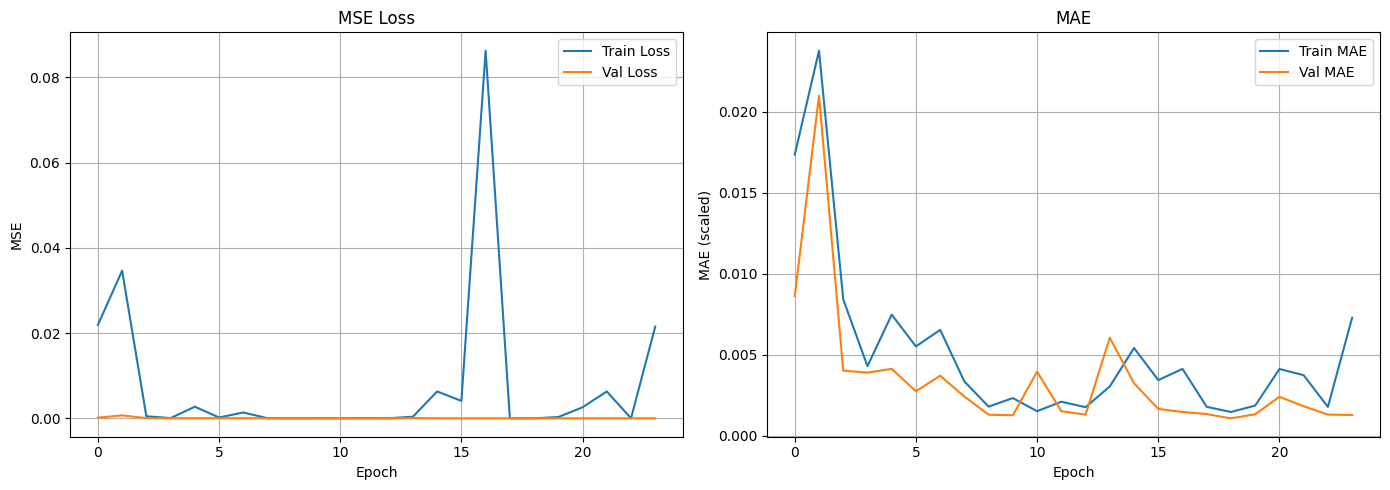

Plot saved to training_history.png


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True)

# MAE
if 'mae' in history.history:
    axes[1].plot(history.history['mae'],     label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_title('MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE (scaled)')
    axes[1].legend()
    axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print('Plot saved to training_history.png')

## Step 8 — Quick Inference Check
Run a few predictions to verify the model outputs make sense.

In [26]:
print('Running inference check...')

# Grab one batch from val set
for X_test, y_true in val_dataset.take(1):
    y_pred = model.predict(X_test[:8], verbose=0)   # predict 8 samples

    print(f'\n{"Sample":<8} {"True (t+1)":<40} {"Pred (t+1)":<40} {"MSE"}')
    print('-' * 100)
    for i in range(8):
        t = y_true[i, 0].numpy()   # first future step
        p = y_pred[i, 0]
        mse = np.mean((t - p) ** 2)
        print(f'{i:<8} {str(np.round(t, 4)):<40} {str(np.round(p, 4)):<40} {mse:.6f}')
    break

print('\nInference check complete.')

Running inference check...

Sample   True (t+1)                               Pred (t+1)                               MSE
----------------------------------------------------------------------------------------------------
0        [0.1953 0.6096 0.297 ]                   [0.1958 0.6091 0.2969]                   0.000000
1        [0.2201 0.59   0.2928]                   [0.2204 0.5902 0.2935]                   0.000000
2        [0.1869 0.6028 0.2987]                   [0.1874 0.6021 0.2981]                   0.000000
3        [0.2139 0.5988 0.29  ]                   [0.2145 0.5987 0.2903]                   0.000000
4        [0.1805 0.5949 0.3044]                   [0.181  0.5941 0.3033]                   0.000001
5        [0.2067 0.6067 0.292 ]                   [0.2074 0.6065 0.2919]                   0.000000
6        [0.1767 0.5866 0.3135]                   [0.1771 0.5861 0.312 ]                   0.000001
7        [0.1993 0.6132 0.2987]                   [0.1999 0.613  0.2982]    

In [27]:
print('Running inference check...')

for X_test, y_true in val_dataset.take(1):

    y_pred = model.predict(X_test[:8], verbose=0)

    print(f'\n{"Sample":<8} {"True (t+1)":<40} {"Pred (t+1)":<40} {"MSE"}')
    print('-' * 100)

    for i in range(8):
        t = y_true[i, 0].numpy()
        p = y_pred[i, 0]

        mse = np.mean((t - p) ** 2)

        print(
            f'{i:<8} '
            f'{str(np.round(t,4)):<40} '
            f'{str(np.round(p,4)):<40} '
            f'{mse:.8f}'
        )

    # overall batch metrics
    batch_mae = np.mean(np.abs(y_true.numpy()[:8] - y_pred))
    batch_rmse = np.sqrt(np.mean((y_true.numpy()[:8] - y_pred) ** 2))

    print("\nBatch MAE :", batch_mae)
    print("Batch RMSE:", batch_rmse)

    break

print('\nInference check complete.')

Running inference check...

Sample   True (t+1)                               Pred (t+1)                               MSE
----------------------------------------------------------------------------------------------------
0        [0.1953 0.6096 0.297 ]                   [0.1958 0.6091 0.2969]                   0.00000017
1        [0.2201 0.59   0.2928]                   [0.2204 0.5902 0.2935]                   0.00000019
2        [0.1869 0.6028 0.2987]                   [0.1874 0.6021 0.2981]                   0.00000037
3        [0.2139 0.5988 0.29  ]                   [0.2145 0.5987 0.2903]                   0.00000015
4        [0.1805 0.5949 0.3044]                   [0.181  0.5941 0.3033]                   0.00000066
5        [0.2067 0.6067 0.292 ]                   [0.2074 0.6065 0.2919]                   0.00000019
6        [0.1767 0.5866 0.3135]                   [0.1771 0.5861 0.312 ]                   0.00000093
7        [0.1993 0.6132 0.2987]                   [0.1999 0.61

In [28]:
print("Evaluating in real coordinates (km)...")

for X_test, y_true in val_dataset.take(1):

    y_pred = model.predict(X_test, verbose=0)

    # First future timestep
    true_xyz = y_true[:, 0, :].numpy()
    pred_xyz = y_pred[:, 0, :]

    # Convert back to km
    true_xyz_km = position_scaler.inverse_transform(true_xyz)
    pred_xyz_km = position_scaler.inverse_transform(pred_xyz)

    mae_km = np.mean(np.abs(true_xyz_km - pred_xyz_km))
    rmse_km = np.sqrt(np.mean((true_xyz_km - pred_xyz_km) ** 2))

    print(f"MAE (km)  : {mae_km:.4f}")
    print(f"RMSE (km) : {rmse_km:.4f}")

    print("\nFirst 5 samples:")
    for i in range(5):
        print(f"\nSample {i}")
        print("True :", np.round(true_xyz_km[i], 3))
        print("Pred :", np.round(pred_xyz_km[i], 3))

    break

Evaluating in real coordinates (km)...
MAE (km)  : 90.4033
RMSE (km) : 109.3297

First 5 samples:

Sample 0
True : [-2049.154  3607.978 -5536.204]
Pred : [-1937.307  3514.95  -5558.441]

Sample 1
True : [ 3263.215  -362.464 -6131.172]
Pred : [ 3330.323  -322.027 -6037.251]

Sample 2
True : [-3837.79   2237.686 -5304.173]
Pred : [-3730.46   2090.613 -5384.09 ]

Sample 3
True : [ 1924.567  1411.823 -6532.99 ]
Pred : [ 2051.468  1400.505 -6488.871]

Sample 4
True : [-5215.524   627.85  -4502.712]
Pred : [-5111.722   474.391 -4654.856]


## Notes on Resuming After Session Crash

If the Kaggle session times out mid-training:
1. Re-run all cells from the top
2. **Step 2** (TFRecord writing) is skipped automatically if files already exist
3. **Step 4** loads the last saved checkpoint (`trajectory_model_best.keras`)
4. Training resumes from where it left off with the same callbacks

The only thing not preserved across sessions is the `history` object (loss curves). The model weights are always safe.